<a href="https://colab.research.google.com/github/Zuhair0000/tensorflow_bootcamp/blob/main/08_intoduction_to_NLP_in_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-03-01 06:55:48--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-03-01 06:55:48 (93.0 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [2]:
from helper_functions import unzip_data, create_tensorboard_callback, plot_loss_curves, compare_historys

In [3]:
!wget https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip
unzip_data("nlp_getting_started.zip")

--2026-03-01 06:56:05--  https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.137.207, 142.250.141.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.137.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 607343 (593K) [application/zip]
Saving to: ‘nlp_getting_started.zip’

nlp_getting_started 100%[===================>] 593.11K  --.-KB/s    in 0.003s  

2026-03-01 06:56:05 (197 MB/s) - ‘nlp_getting_started.zip’ saved [607343/607343]



# Visualizing a text dataset

In [4]:
import pandas as pd
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [5]:
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [6]:
train_df_shuffled = train_df.sample(frac=1, random_state=42)
train_df_shuffled.head()

,id,keyword,location,text,target
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0


In [7]:
test_df.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [8]:
train_df_shuffled.target.value_counts()

,count
target,
0,4342
1,3271


In [9]:
len(train_df_shuffled)

7613

In [10]:
len(test_df)

3263

In [11]:
import random
random_index = random.randint(0, len(train_df)-5)
for row in train_df_shuffled[['text', 'target']][random_index: random_index+5].itertuples():
  _, text, target = row
  print(f"Target: {target}", "(real disaster)" if target > 0 else "(not real disaster)")
  print(f"Text:\n{text}\n")
  print("---\n")

Target: 1 (real disaster)
Text:
@abc3340 
Parents of Colorado theater shooting victim fear copycat massacre

http://t.co/LvlH3W3aWO
#Antioch

http://t.co/vIwXY1XDYK

---

Target: 0 (not real disaster)
Text:
@TheEconomist Step one: get that mass murderer's portrait off the yuan.

---

Target: 0 (not real disaster)
Text:
The injuries are starting!!! Please @dallascowboys stay healthy!!! ????????????

---

Target: 1 (real disaster)
Text:
.@unsuckdcmetro Is the train half-derailed or half-railed? #deepthoughts

---

Target: 0 (not real disaster)
Text:
That horrible sinking feeling when youÛªve been at home on your phone for a while and you realise its been on 3G this whole time.

---



# Split Data

In [12]:
from sklearn.model_selection import train_test_split
train_sentences, val_sentences, train_labels, val_labels = train_test_split(train_df_shuffled['text'].to_numpy(),
                                                                            train_df_shuffled['target'].to_numpy(),
                                                                            test_size=0.1,
                                                                            random_state=42)


In [13]:
len(train_sentences), len(train_labels), len(val_sentences), len(val_labels)

(6851, 6851, 762, 762)

# Converting text to numbers

In [14]:
train_sentences[:5]

array(['@mogacola @zamtriossu i screamed after hitting tweet',
       'Imagine getting flattened by Kurt Zouma',
       '@Gurmeetramrahim #MSGDoing111WelfareWorks Green S welfare force ke appx 65000 members har time disaster victim ki help ke liye tyar hai....',
       "@shakjn @C7 @Magnums im shaking in fear he's gonna hack the planet",
       'Somehow find you and I collide http://t.co/Ee8RpOahPk'],
      dtype=object)

In [15]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

text_vectorizer = TextVectorization(max_tokens=None,
                                    standardize='lower_and_strip_punctuation',
                                    split="whitespace",
                                    ngrams=None,
                                    output_mode='int',
                                    output_sequence_length=None,
                                    pad_to_max_tokens=False
                                   )

In [16]:
round(sum([len(i.split()) for i in train_sentences])/len(train_sentences))

15

In [17]:
max_vocab_length = 10000
max_length = 15

text_vectorizer = TextVectorization(max_tokens=max_vocab_length,
                                    output_mode = 'int',
                                    output_sequence_length=max_length)

In [18]:
text_vectorizer.adapt(train_sentences)

In [19]:
sample_sentence = "There's a flood in my street!"
text_vectorizer([sample_sentence])

<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[264,   3, 232,   4,  13, 698,   0,   0,   0,   0,   0,   0,   0,
          0,   0]])>

In [20]:
random_sentence = random.choice(train_sentences)
print(f" Original text:\n {random_sentence} \
        \n\nVectorized version:")
text_vectorizer([random_sentence])

 Original text:
 I've been trying to write a theological short story about a monster living in a sinkhole. Then I heard about Brooklyn. #accidentalprophecy         

Vectorized version:


<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[ 276,   59,  563,    5, 1917,    3, 4433, 1254,  451,   54,    3,
        5095, 1195,    4,    3]])>

In [21]:
words_in_vocab = text_vectorizer.get_vocabulary()
top_5_words = words_in_vocab[:5]
bottom_5_words = words_in_vocab[-5:]

print(f"Number of words in vocab: {len(words_in_vocab)}")
print(f"5 most common words: {top_5_words}")
print(f"5 least common words: {bottom_5_words}")

Number of words in vocab: 10000
5 most common words: ['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('in')]
5 least common words: [np.str_('pages'), np.str_('paeds'), np.str_('pads'), np.str_('padres'), np.str_('paddytomlinson1')]


# Creating an embedding layer

In [22]:
embedding = tf.keras.layers.Embedding(input_dim=max_vocab_length,
                                      output_dim=128,
                                      input_length=max_length
                                      )

embedding

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


<Embedding name=embedding, built=False>

In [23]:
random_sentences = random.choice(train_sentences)
print(f"Original text:\n {random_sentence}\
        \n\nEmbedded version:")
sample_embed = embedding(text_vectorizer([random_sentence]))
sample_embed

Original text:
 I've been trying to write a theological short story about a monster living in a sinkhole. Then I heard about Brooklyn. #accidentalprophecy        

Embedded version:


<tf.Tensor: shape=(1, 15, 128), dtype=float32, numpy=
array([[[ 0.0207379 , -0.01078893,  0.04976017, ..., -0.02207141,
          0.02090253, -0.01431364],
        [ 0.03255827, -0.0038334 , -0.04850519, ..., -0.04273094,
          0.0027454 ,  0.0003028 ],
        [ 0.02004078,  0.01402042, -0.00701413, ...,  0.00953991,
         -0.02897669,  0.03669499],
        ...,
        [ 0.03577339,  0.02346126, -0.01210693, ..., -0.04450427,
         -0.03724637,  0.04544914],
        [-0.00505758,  0.02017715, -0.0142672 , ..., -0.00656396,
         -0.01239408, -0.01009744],
        [-0.04785528,  0.02519988,  0.00763885, ...,  0.00988642,
          0.00244056,  0.00316527]]], dtype=float32)>

## Modelling a text dataset

### Model 0

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

model_0 = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', MultinomialNB())
])

model_0.fit(train_sentences, train_labels)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('model', MultinomialNB())])

In [25]:
baseline_score = model_0.score(val_sentences, val_labels)
print(f"Baseline model acieves an accuracy of: {baseline_score*100:.2f}")

Baseline model acieves an accuracy of: 79.27


In [26]:
baseline_prediction = model_0.predict(val_sentences)

In [27]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate(y_pred, y_true):
  model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
  return{
      "Accuracy Score": accuracy_score(y_true, y_pred),
      "Model Precision": model_precision,
      "Recall": model_recall,
      "F1": model_f1
  }

In [28]:
baseline_results = evaluate(val_labels, baseline_prediction)
baseline_results

{'Accuracy Score': 0.7926509186351706,
 'Model Precision': 0.8336022277575122,
 'Recall': 0.7926509186351706,
 'F1': 0.7990828614653861}

### Model 1

In [29]:
from helper_functions import create_tensorboard_callback

SAVE_DIR = 'model_logs'

In [30]:
inputs = tf.keras.layers.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)


model_1 = tf.keras.Model(inputs, outputs, name='model_1_dense')

In [31]:
model_1.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

In [32]:
history_1 = model_1.fit(x = train_sentences,
                        y=train_labels,
                        epochs=5,
                        validation_data = (val_sentences, val_labels),
                        callbacks=[create_tensorboard_callback(dir_name='SAVE_DIR',
                                                               experiment_name='model_1_dense')])

Saving TensorBoard log files to: SAVE_DIR/model_1_dense/20260301-065610
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6553 - loss: 0.6492 - val_accuracy: 0.7585 - val_loss: 0.5376
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8065 - loss: 0.4643 - val_accuracy: 0.7874 - val_loss: 0.4777
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8531 - loss: 0.3660 - val_accuracy: 0.7953 - val_loss: 0.4632
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8878 - loss: 0.2913 - val_accuracy: 0.7913 - val_loss: 0.4722
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9044 - loss: 0.2514 - val_accuracy: 0.7769 - val_loss: 0.4791


In [33]:
model_1.evaluate(val_sentences, val_labels)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7692 - loss: 0.5094


[0.4791105091571808, 0.7769029140472412]

In [34]:
model_1_pred_probs = model_1.predict(val_sentences)
model_1_pred_probs.shape

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


(762, 1)

In [35]:
model_1_preds = tf.squeeze(tf.round(model_1_pred_probs))
model_1_preds[:20]

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1.], dtype=float32)>

In [36]:
model_1_results = evaluate(val_labels,
                           model_1_preds)
model_1_results, baseline_results

({'Accuracy Score': 0.7769028871391076,
  'Model Precision': 0.7889443292352074,
  'Recall': 0.7769028871391076,
  'F1': 0.7793184078274801},
 {'Accuracy Score': 0.7926509186351706,
  'Model Precision': 0.8336022277575122,
  'Recall': 0.7926509186351706,
  'F1': 0.7990828614653861})

# Visualizing Embeddings

In [37]:
words_in_vocab = text_vectorizer.get_vocabulary()
len(words_in_vocab), words_in_vocab[:10]

(10000,
 ['',
  '[UNK]',
  np.str_('the'),
  np.str_('a'),
  np.str_('in'),
  np.str_('to'),
  np.str_('of'),
  np.str_('and'),
  np.str_('i'),
  np.str_('is')])

In [38]:
model_1.summary()

Model: "model_1_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,840,389 (14.65 MB)

 Trainable params: 1,280,129 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,560,260 (9.77 MB)

In [39]:
embed_weights = model_1.get_layer('embedding').get_weights()[0]
print(embed_weights.shape)

(10000, 128)


In [40]:
import io
out_v = io.open("vectors.tsv", 'w', encoding='utf-8')
out_m = io.open("metadata.tsv", 'w', encoding='utf-8')

for index, word in enumerate(words_in_vocab):
  if index == 0:
    continue
  vec = embed_weights[index]
  out_v.write('\t'.join([str(x) for x in vec]) + '\n')
  out_m.write(word + '\n')
out_v.close()
out_m.close()

In [41]:
try:
  from google.colab import files
  files.download('vectors.tsv')
  files.download('metadata.tsv')
except:
  pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# RNN

## LSTM

In [42]:
inputs = tf.keras.layers.Input(shape=(1,), dtype='string')
x = text_vectorizer(inputs)
x = embedding(x)
x = tf.keras.layers.LSTM(64, return_sequences=True)(x)
x = tf.keras.layers.LSTM(64)(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model_2 = tf.keras.Model(inputs, outputs, name='model_2_LSTM')

In [43]:
model_2.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

In [44]:
history_2 = model_2.fit(train_sentences,
                        train_labels,
                        epochs=5,
                        validation_data=(val_sentences, val_labels),
                        callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR,
                                                               experiment_name='model_2_LSTM')])

Saving TensorBoard log files to: model_logs/model_2_LSTM/20260301-065623
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8980 - loss: 0.2952 - val_accuracy: 0.7756 - val_loss: 0.6750
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9448 - loss: 0.1484 - val_accuracy: 0.7782 - val_loss: 0.6013
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9573 - loss: 0.1246 - val_accuracy: 0.7690 - val_loss: 0.7552
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9632 - loss: 0.0983 - val_accuracy: 0.7874 - val_loss: 0.9906
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9630 - loss: 0.0834 - val_accuracy: 0.7690 - val_loss: 1.1097


In [45]:
model_2_pred_probs = model_2.predict(val_sentences)
model_2_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


array([[6.5378086e-03],
       [7.1970093e-01],
       [9.9995315e-01],
       [1.4217071e-02],
       [1.1831206e-04],
       [9.9987042e-01],
       [9.9343252e-01],
       [9.9996638e-01],
       [9.9995053e-01],
       [1.5585242e-01]], dtype=float32)

In [46]:
model_2_preds = tf.squeeze(tf.round(model_2_pred_probs))
model_2_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0.], dtype=float32)>

In [47]:
model_2_results = evaluate(val_labels,
                           model_2_preds)
model_2_results

{'Accuracy Score': 0.7690288713910761,
 'Model Precision': 0.7773727965413619,
 'Recall': 0.7690288713910761,
 'F1': 0.7708702103474017}

In [48]:
baseline_results

{'Accuracy Score': 0.7926509186351706,
 'Model Precision': 0.8336022277575122,
 'Recall': 0.7926509186351706,
 'F1': 0.7990828614653861}

## GRU

In [49]:
inputs = tf.keras.layers.Input(shape=(1,), dtype='string')
x = text_vectorizer(inputs)
x = embedding(x)
x = tf.keras.layers.GRU(64, return_sequences=True)(x)
x = tf.keras.layers.LSTM(64, return_sequences=True)(x)
x = tf.keras.layers.GRU(64)(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model_3 = tf.keras.Model(inputs, outputs, name='model_3_GRU')

In [50]:
model_3.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

In [51]:
history_3 = model_3.fit(train_sentences,
                        train_labels,
                        epochs=5,
                        validation_data=(val_sentences, val_labels),
                        callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR,
                                                               experiment_name='model_3_GRU')])

Saving TensorBoard log files to: model_logs/model_3_GRU/20260301-065639
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9263 - loss: 0.2339 - val_accuracy: 0.7756 - val_loss: 0.9011
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9664 - loss: 0.0876 - val_accuracy: 0.7717 - val_loss: 1.0504
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9745 - loss: 0.0612 - val_accuracy: 0.7677 - val_loss: 1.1273
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9729 - loss: 0.0632 - val_accuracy: 0.7730 - val_loss: 1.0428
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9744 - loss: 0.0541 - val_accuracy: 0.7690 - val_loss: 1.2971


In [52]:
model_3_pred_probs = model_3.predict(val_sentences)
model_3_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


array([[5.9992038e-03],
       [9.2012578e-01],
       [9.9999452e-01],
       [1.2263175e-01],
       [1.0945336e-04],
       [9.9982339e-01],
       [9.8301679e-01],
       [9.9999630e-01],
       [9.9999475e-01],
       [2.1629748e-01]], dtype=float32)

In [53]:
model_3_preds = tf.squeeze(tf.round(model_3_pred_probs))
model_3_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0.], dtype=float32)>

In [54]:
model_3_results = evaluate(val_labels,
                           model_3_preds)
model_3_results

{'Accuracy Score': 0.7690288713910761,
 'Model Precision': 0.7866298696670911,
 'Recall': 0.7690288713910761,
 'F1': 0.7724376523094117}

# Bidirectional LSTM

In [55]:
inputs = tf.keras.layers.Input(shape=(1,), dtype='string')
x = text_vectorizer(inputs)
x = embedding(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64))(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model_4 = tf.keras.Model(inputs, outputs)

In [56]:
model_4.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

In [57]:
history_4 = model_4.fit(train_sentences,
                        train_labels,
                        epochs=5,
                        validation_data=(val_sentences, val_labels),
                        callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR,
                                                               experiment_name='model_4_Bidirectional')])

Saving TensorBoard log files to: model_logs/model_4_Bidirectional/20260301-065655
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9348 - loss: 0.1772 - val_accuracy: 0.7717 - val_loss: 1.0427
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9722 - loss: 0.0610 - val_accuracy: 0.7743 - val_loss: 1.0548
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9801 - loss: 0.0446 - val_accuracy: 0.7677 - val_loss: 1.3334
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9787 - loss: 0.0448 - val_accuracy: 0.7677 - val_loss: 1.2036
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9768 - loss: 0.0440 - val_accuracy: 0.7677 - val_loss: 1.4568


In [58]:
model_4_pred_probs = model_4.predict(val_sentences)
model_4_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


array([[2.9754850e-01],
       [6.8204898e-01],
       [9.9998963e-01],
       [2.5187999e-01],
       [3.4988603e-05],
       [9.9996233e-01],
       [9.9921203e-01],
       [9.9999380e-01],
       [9.9998689e-01],
       [4.1473100e-01]], dtype=float32)

In [59]:
model_4_preds = tf.squeeze(tf.round(model_4_pred_probs))
model_4_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0.], dtype=float32)>

In [60]:
model_4_results = evaluate(val_labels,
                           model_4_preds)
model_4_results

{'Accuracy Score': 0.7677165354330708,
 'Model Precision': 0.7721781607009267,
 'Recall': 0.7677165354330708,
 'F1': 0.7688360590053837}

# Convolutional Nueral Netowrks for Text

In [61]:
embedding_test = embedding(text_vectorizer(['this is a test sentence']))
conv_1d = tf.keras.layers.Conv1D(filters=32,
                                 kernel_size=5, # It means it lokks at 5 words at a time
                                 activation='relu',
                                 padding='valid', #default = 'valid', the output is smaller the the input shape, 'same' means output is
                                 )
conv_1d_output = conv_1d(embedding_test) # pass test embedding through conv1D layer
max_pool = tf.keras.layers.GlobalMaxPool1D()
max_pool_output = max_pool(conv_1d_output)

embedding_test.shape, conv_1d_output.shape, max_pool_output.shape

(TensorShape([1, 15, 128]), TensorShape([1, 11, 32]), TensorShape([1, 32]))

In [62]:
inputs = tf.keras.layers.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='valid')(x)
x = tf.keras.layers.GlobalMaxPool1D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model_5 = tf.keras.Model(inputs, outputs)

In [63]:
model_5.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

In [64]:
history_5 = model_5.fit(train_sentences,
                        train_labels,
                        epochs=5,
                        validation_data=(val_sentences, val_labels),
                        callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR,
                                                               experiment_name='Conv1D')])

Saving TensorBoard log files to: model_logs/Conv1D/20260301-065716
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9428 - loss: 0.1834 - val_accuracy: 0.7677 - val_loss: 0.8286
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9705 - loss: 0.0810 - val_accuracy: 0.7677 - val_loss: 0.9966
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9812 - loss: 0.0546 - val_accuracy: 0.7612 - val_loss: 1.0558
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9799 - loss: 0.0478 - val_accuracy: 0.7638 - val_loss: 1.2122
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9803 - loss: 0.0481 - val_accuracy: 0.7533 - val_loss: 1.1938


In [65]:
model_5_pred_probs = model_5.predict(val_sentences)
model_5_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


array([[6.0782248e-01],
       [8.3713782e-01],
       [9.9992883e-01],
       [7.4821986e-02],
       [1.2460301e-06],
       [9.9621260e-01],
       [9.4340700e-01],
       [9.9996281e-01],
       [9.9999940e-01],
       [7.5831503e-01]], dtype=float32)

In [66]:
model_5_preds = tf.squeeze(tf.round(model_5_pred_probs))
model_5_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([1., 1., 1., 0., 0., 1., 1., 1., 1., 1.], dtype=float32)>

In [67]:
model_5_results = evaluate(val_labels,
                           model_5_preds)
model_5_results

{'Accuracy Score': 0.7532808398950132,
 'Model Precision': 0.7592141156018666,
 'Recall': 0.7532808398950132,
 'F1': 0.754750837203943}

# Model 6: Tensorflow hub for pretrained word embeddings

In [68]:
import tensorflow_hub as hub

embed = hub.load('https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2')
embed_samples = embed([sample_sentence,
                       "When you can the universsal the sentence encoder on a sentence, it turns is into numbers"])

print(embed_samples[0][:50])

tf.Tensor(
[-0.01157028  0.0248591   0.02878048 -0.012715    0.03971538  0.0882776
  0.02680984  0.05589836 -0.0106873  -0.00597291  0.00639323 -0.01819518
  0.00030813  0.09105888  0.05874644 -0.03180628  0.01512474 -0.05162929
  0.00991367 -0.06865347 -0.04209306  0.02678981  0.03011006  0.00321069
 -0.00337973 -0.04787357  0.0226672  -0.00985925 -0.04063613 -0.01292092
 -0.04666384  0.05630299 -0.03949255  0.00517686  0.02495829 -0.0701444
  0.02871508  0.04947684 -0.00633979 -0.08960192  0.02807118 -0.00808364
 -0.01360602  0.0599865  -0.10361787 -0.05195374  0.00232954 -0.02332531
 -0.03758105  0.03327728], shape=(50,), dtype=float32)


In [69]:
# sentence_encoder_layer = hub.KerasLayer("https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2",
#                                         input_shape=[],
#                                         dtype=tf.string,
#                                         trainable=False,
#                                         name='USE')

In [70]:
from keras.layers import Layer

class HubLayerWrapper(Layer):
    def __init__(self, hub_url, **kwargs):
        super().__init__(**kwargs)
        self.hub_layer = hub.KerasLayer(hub_url, trainable=False)

    def call(self, inputs):
        return self.hub_layer(inputs)

# 2. Use the wrapper in your Functional model
sentence_encoder_layer = HubLayerWrapper("https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2")

In [75]:
inputs = tf.keras.layers.Input(shape=[], dtype=tf.string)
x = sentence_encoder_layer(inputs)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model_6 = tf.keras.Model(inputs, outputs)

In [76]:
model_6.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hub_layer_wrapper               │ (None, 512)            │             0 │
│ (HubLayerWrapper)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,897 (128.50 KB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
model_6.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'],
                jit_compile=False
                )

In [80]:
history_6 = model_6.fit(train_sentences,
                        train_labels,
                        epochs=5,
                        validation_data=(val_sentences, val_labels),
                        callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR,
                                                               experiment_name='tf_hub_sentence_encoder')])

Saving TensorBoard log files to: model_logs/tf_hub_sentence_encoder/20260301-070027
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7583 - loss: 0.5768 - val_accuracy: 0.8084 - val_loss: 0.4483
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8172 - loss: 0.4155 - val_accuracy: 0.8031 - val_loss: 0.4422
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8233 - loss: 0.4000 - val_accuracy: 0.8097 - val_loss: 0.4334
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8261 - loss: 0.3945 - val_accuracy: 0.8110 - val_loss: 0.4374
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8314 - loss: 0.3875 - val_accuracy: 0.8150 - val_loss: 0.4278


In [81]:
model_6_pred_probs = model_6.predict(val_sentences)
model_6_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


array([[0.2102094 ],
       [0.7885285 ],
       [0.98703104],
       [0.2214672 ],
       [0.76507246],
       [0.77599376],
       [0.98241067],
       [0.97992355],
       [0.9340913 ],
       [0.09552101]], dtype=float32)

In [82]:
model_6_preds = tf.squeeze(tf.round(model_6_pred_probs))
model_6_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 1., 1., 1., 1., 1., 0.], dtype=float32)>

In [83]:
model_6_results = evaluate(val_labels,
                           model_6_preds)
model_6_results

{'Accuracy Score': 0.8149606299212598,
 'Model Precision': 0.8201386511468675,
 'Recall': 0.8149606299212598,
 'F1': 0.8160196314716812}

# Model 7: TF hub Pretrained USE but with 10% of training data

In [103]:
# import numpy as np

# train_10_percent = train_df_shuffled[['text', 'target']].sample(frac=0.1, random_state=42)
# train_sentences_10_percent = np.array(train_10_percent['text'].to_list(), dtype=object)
# train_labels_10_percent = np.array(train_10_percent['target'].to_list())


# val_sentences_arr = np.array(val_sentences, dtype=object)
# val_labels_arr = np.array(val_labels)
# len(train_sentences_10_percent), len(train_labels_10_percent)

(761, 761)

In [111]:
train_10_percent_split = int(0.1 * len(train_sentences))
train_sentences_10_percent = train_sentences[:train_10_percent_split]

train_labels_10_percent = train_labels[:train_10_percent_split]

In [112]:
model_7 = tf.keras.models.clone_model(model_6)

model_7.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'],
                jit_compile=False
                )

In [113]:
history_7 = model_7.fit(train_sentences_10_percent,
                        train_labels_10_percent,
                        epochs=5,
                        validation_data=(val_sentences, val_labels),
                        callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR,
                                                               experiment_name='tf_hub_sentence_encoder_10_percent_correct_split')])

Saving TensorBoard log files to: model_logs/tf_hub_sentence_encoder_10_percent_correct_split/20260301-073524
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.5971 - loss: 0.6810 - val_accuracy: 0.7165 - val_loss: 0.6491
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7988 - loss: 0.6124 - val_accuracy: 0.7520 - val_loss: 0.5901
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8154 - loss: 0.5284 - val_accuracy: 0.7769 - val_loss: 0.5354
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8178 - loss: 0.4708 - val_accuracy: 0.7782 - val_loss: 0.5028
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8331 - loss: 0.4329 - val_accuracy: 0.7690 - val_loss: 0.4943


In [114]:
model_7_pred_probs = model_7.predict(val_sentences)
model_7_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


array([[0.20514907],
       [0.5326194 ],
       [0.90344864],
       [0.37649608],
       [0.5268266 ],
       [0.7077672 ],
       [0.87806714],
       [0.80348825],
       [0.8241397 ],
       [0.15349954]], dtype=float32)

In [115]:
model_7_preds = tf.squeeze(tf.round(model_7_pred_probs))
model_7_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 1., 1., 1., 1., 1., 0.], dtype=float32)>

In [116]:
model_7_results = evaluate(val_labels,
                           model_7_preds)
model_7_results

{'Accuracy Score': 0.7690288713910761,
 'Model Precision': 0.7803503104091,
 'Recall': 0.7690288713910761,
 'F1': 0.771390755891333}

# Comparing all results

In [126]:
all_models_results = pd.DataFrame({'0_baseline': baseline_results,
                                   '1_simple_dense': model_1_results,
                                   '2_lstm': model_2_results,
                                   '3_gru': model_3_results,
                                   "4_bidirectional": model_4_results,
                                   '5_conv1D': model_5_results,
                                   "6_tf_hub_use_encoder": model_6_results,
                                   '7_tf_hub_use_encoder_10_percent': model_7_results})
all_models_results.transpose()

,Accuracy Score,Model Precision,Recall,F1
0_baseline,0.792651,0.833602,0.792651,0.799083
1_simple_dense,0.776903,0.788944,0.776903,0.779318
2_lstm,0.769029,0.777373,0.769029,0.770870
3_gru,0.769029,0.786630,0.769029,0.772438
4_bidirectional,0.767717,0.772178,0.767717,0.768836
5_conv1D,0.753281,0.759214,0.753281,0.754751
6_tf_hub_use_encoder,0.814961,0.820139,0.814961,0.816020
7_tf_hub_use_encoder_10_percent,0.769029,0.780350,0.769029,0.771391


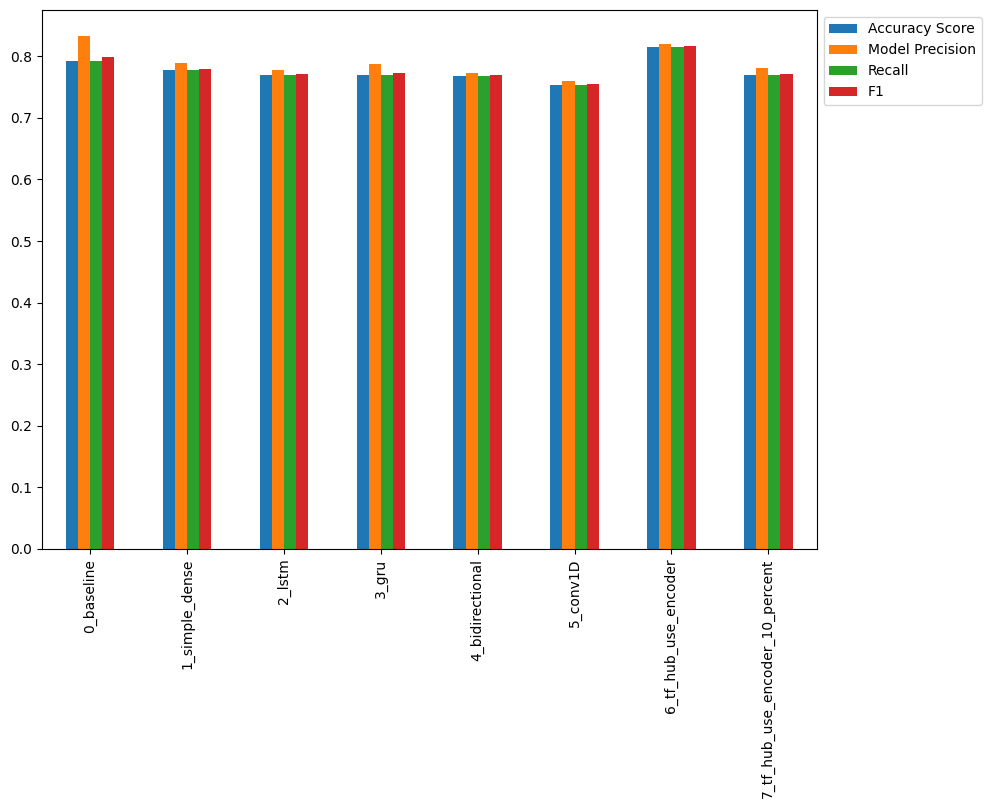

In [128]:
all_models_results.transpose().plot(kind='bar', figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0))